In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# paths

res = "gridsearch_results"
par = "gridsearch_segments"

results_csv = f"/Users/chrismader/Python/SLDS/DRO/{res}.csv"
segments_parquet = f"/Users/chrismader/Python/SLDS/DRO/{par}.parquet"
out = f"/Users/chrismader/Python/SLDS/temp_parquet/"

In [3]:
def list_configs_from_parquet(path: str) -> list[str]:
    """
    Return a sorted list of unique config values in a segments parquet.
    Expects a 'config' column.
    """
    df = pd.read_parquet(path, columns=["config"])
    if "config" not in df.columns:
        raise ValueError("missing column: 'config'")
    return sorted(df["config"].dropna().astype(str).unique().tolist())

configs = list_configs_from_parquet(segments_parquet)
configs

['[g,v,h]',
 '[g,v]',
 '[y,h]',
 '[y]',
 'factor2_ff3',
 'factor2_ff3mom',
 'fund2',
 'fund2_vix']

In [4]:
import pandas as pd, re
import pyarrow.parquet as pq

path = segments_parquet  # your path

# 1) Pandas columns
df = pd.read_parquet(path)
cols = list(df.columns)
print("COLUMNS:", sorted(cols))

# 2) Check expected names
targets = ["n_regimes","K","k","nStates","n_states","dim_latent","latent_dim","D","dim"]
present = [c for c in targets if c in cols]
print("TARGET COLUMNS FOUND:", present)

# 3) Fuzzy search for likely fields
hits = [c for c in cols if re.search(r"(regime|state|latent|dim)", c, re.I)]
print("FUZZY HITS:", hits)

# 4) Arrow-level schema (authoritative)
pf = pq.ParquetFile(path)
print(pf.schema_arrow)  # full field list with types

# 5) Quick peek if any target exists
for c in present:
    print(c, df[c].dropna().unique()[:10])


COLUMNS: ['config', 'date', 'dim_latent', 'dt', 'n_regimes', 'overlap_window', 'security', 'single_subspace', 't', 'train_window', 'z']
TARGET COLUMNS FOUND: ['n_regimes', 'dim_latent']
FUZZY HITS: ['n_regimes', 'dim_latent']
security: string
config: string
date: timestamp[ns]
t: int32
z: int16
dt: string
n_regimes: int16
dim_latent: string
single_subspace: bool
train_window: int32
overlap_window: int32
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 1331
n_regimes <IntegerArray>
[3, 4, 5, 6]
Length: 4, dtype: Int16
dim_latent <StringArray>
['1', '2', '3', '4']
Length: 4, dtype: string


In [5]:
import pandas as pd
import numpy as np
import ast

def _first_present(df, cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

def _parse_dim(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float)):
        return int(v) if np.isfinite(v) else np.nan
    s = str(v).strip()
    try:
        lit = ast.literal_eval(s)
        if isinstance(lit, (list, tuple)):
            # keep the vector as a tuple
            return tuple(int(x) for x in lit)
        if isinstance(lit, (int, float)):
            return int(lit)
    except Exception:
        pass
    # fallback to numeric if possible
    try:
        x = pd.to_numeric(s, errors="coerce")
        return int(x) if np.isfinite(x) else np.nan
    except Exception:
        return np.nan

REQUIRED_COLS = [
    "config", "dt", "n_regimes", "dim_latent",
    "single_subspace", "train_window", "overlap_window",
]

def list_config_tuples(segments_parquet: str):
    """
    Strict: expects the new parquet schema with REQUIRED_COLS.
    Returns a sorted, deduped list of (config, n_regimes, dim_latent).
    """
    seg = pd.read_parquet(segments_parquet, columns=REQUIRED_COLS)

    missing = [c for c in REQUIRED_COLS if c not in seg.columns]
    if missing:
        raise ValueError(f"Parquet missing required columns: {missing}")

    # enforce types
    seg["config"] = seg["config"].astype(str).str.strip()
    seg["n_regimes"] = pd.to_numeric(seg["n_regimes"], errors="raise").astype(int)
    seg["dim_latent"] = pd.to_numeric(seg["dim_latent"], errors="raise").astype(int)

    out = (
        seg.loc[:, ["config", "n_regimes", "dim_latent"]]
           .drop_duplicates()
           .sort_values(["config", "n_regimes", "dim_latent"])
    )
    return list(out.itertuples(index=False, name=None))

    
# usage
tuples = list_config_tuples(segments_parquet)
for t in tuples:
    print(t)

('[g,v,h]', 3, 2)
('[g,v,h]', 3, 3)
('[g,v,h]', 4, 2)
('[g,v,h]', 4, 3)
('[g,v,h]', 5, 2)
('[g,v,h]', 5, 3)
('[g,v,h]', 6, 2)
('[g,v,h]', 6, 3)
('[g,v]', 3, 2)
('[g,v]', 4, 2)
('[g,v]', 5, 2)
('[g,v]', 6, 2)
('[y,h]', 3, 2)
('[y,h]', 4, 2)
('[y,h]', 5, 2)
('[y,h]', 6, 2)
('[y]', 3, 1)
('[y]', 4, 1)
('[y]', 5, 1)
('[y]', 6, 1)
('factor2_ff3', 3, 3)
('factor2_ff3', 4, 3)
('factor2_ff3', 5, 3)
('factor2_ff3', 6, 3)
('factor2_ff3mom', 3, 4)
('factor2_ff3mom', 4, 4)
('factor2_ff3mom', 5, 4)
('factor2_ff3mom', 6, 4)
('fund2', 3, 2)
('fund2', 4, 2)
('fund2', 5, 2)
('fund2', 6, 2)
('fund2_vix', 3, 3)
('fund2_vix', 4, 3)
('fund2_vix', 5, 3)
('fund2_vix', 6, 3)


In [6]:
import os
import pandas as pd
import numpy as np

# --- REQUIRED NEW-SCHEMA COLUMNS ---
REQ_COLS = {
    "security","config","n_regimes","dim_latent",
    "train_window","overlap_window","date","t","z"
}

def list_model_tuples_strict(path: str):
    """
    Return sorted unique model tuples from the NEW parquet:
    (config, n_regimes, dim_latent, train_window, overlap_window)
    """
    df = pd.read_parquet(path)
    missing = REQ_COLS - set(df.columns)
    if missing:
        raise ValueError(f"parquet missing required columns: {sorted(missing)}")

    # enforce dtypes we match on
    df["n_regimes"]      = pd.to_numeric(df["n_regimes"], errors="raise").astype(int)
    df["dim_latent"]     = pd.to_numeric(df["dim_latent"], errors="raise").astype(int)
    df["train_window"]   = pd.to_numeric(df["train_window"], errors="raise").astype(int)
    df["overlap_window"] = pd.to_numeric(df["overlap_window"], errors="raise").astype(int)

    uniq = (df[["config","n_regimes","dim_latent","train_window","overlap_window"]]
            .drop_duplicates().sort_values(["config","n_regimes","dim_latent","train_window","overlap_window"]))
    return [tuple(x) for x in uniq.itertuples(index=False, name=None)]


def regimes_wide_from_parquet_strict(
    path: str,
    config: str,
    n_regimes: int,
    dim_latent: int,
    train_window: int,
    overlap_window: int,
    value_col: str = "z",
) -> pd.DataFrame:
    """
    NEW SCHEMA ONLY (no backward compat).
    Filters by EXACT model tuple and pivots to wide (date x security) with values=value_col.
    Keeps the last 't' per (security,date).
    """
    df = pd.read_parquet(path)
    missing = REQ_COLS - set(df.columns)
    if missing:
        raise ValueError(f"parquet missing required columns: {sorted(missing)}")

    # enforce dtypes we match on
    df["n_regimes"]      = pd.to_numeric(df["n_regimes"], errors="raise").astype(int)
    df["dim_latent"]     = pd.to_numeric(df["dim_latent"], errors="raise").astype(int)
    df["train_window"]   = pd.to_numeric(df["train_window"], errors="raise").astype(int)
    df["overlap_window"] = pd.to_numeric(df["overlap_window"], errors="raise").astype(int)

    # exact filter
    m = (
        (df["config"].astype(str) == str(config)) &
        (df["n_regimes"] == int(n_regimes)) &
        (df["dim_latent"] == int(dim_latent)) &
        (df["train_window"] == int(train_window)) &
        (df["overlap_window"] == int(overlap_window))
    )
    df = df.loc[m, ["security","date","t",value_col]].copy()
    if df.empty:
        return pd.DataFrame()

    # time + de-dupe by latest t per (security,date)
    df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=False)
    df = df.dropna(subset=["date"])
    df = (df.sort_values(["security","date","t"])
            .drop_duplicates(subset=["security","date"], keep="last"))

    wide = (df.pivot(index="date", columns="security", values=value_col)
              .sort_index())

    # Cast to nullable Int64 if possible
    try:
        wide = wide.astype("Int64")
    except Exception:
        pass
    wide.index.name = None
    return wide


def regime_share_by_security_strict(
    wide_df: pd.DataFrame,
    n_regimes: int,
    decimals: int = 0
) -> pd.DataFrame:
    """
    Percentage of time each security spends in each regime (0..n_regimes-1),
    plus 'Total'=100.
    """
    if wide_df.empty:
        return pd.DataFrame()

    long = (wide_df.astype("Int64")
                  .melt(ignore_index=False, var_name="security", value_name="z")
                  .dropna(subset=["z"]))
    long["z"] = long["z"].astype(int)

    counts = (long.groupby(["security","z"]).size()
                    .unstack(fill_value=0)
                    .reindex(columns=list(range(n_regimes)), fill_value=0))

    totals = counts.sum(axis=1).replace(0, np.nan)
    pct = counts.div(totals, axis=0).multiply(100).fillna(0.0).round(decimals)

    # Row-wise rounding fix to sum exactly 100
    arr = pct.to_numpy(copy=True)
    row_sum = arr.sum(axis=1)
    diff = np.round(100.0 - row_sum, decimals)
    if arr.shape[1] > 0:
        jmax = np.argmax(arr, axis=1)
        for i, j in enumerate(jmax):
            if diff[i] != 0:
                arr[i, j] = np.round(arr[i, j] + diff[i], decimals)
        pct = pd.DataFrame(arr, index=pct.index, columns=pct.columns)

    pct["Total"] = 100.0
    pct.index.name = "security"
    pct.columns.name = "z"
    return pct


# SAVE EACH MODEL AS WIDE CSV (NEW SCHEMA)
# assumes you already have:
# segments_parquet = "/path/to/gridsearch_segments.parquet"
# out = "/path/to/output_prefix_"   (prefix)
# res = "gridsearch_results"        (name piece)

os.makedirs(os.path.dirname(out), exist_ok=True) if os.path.dirname(out) else None

model_tuples = list_model_tuples_strict(segments_parquet)
for (cfg, K, D, TW, OW) in model_tuples:
    wide = regimes_wide_from_parquet_strict(
        path=segments_parquet,
        config=cfg,
        n_regimes=K,
        dim_latent=D,
        train_window=TW,
        overlap_window=OW,
    )
    if wide.empty:
        continue
    fname = f"{out}{res}_{cfg}_K{K}_D{D}_TW{TW}_OW{OW}.csv"
    wide.to_csv(fname)


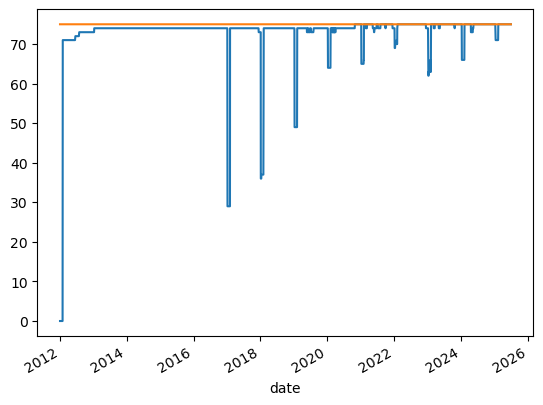

In [7]:
import pandas as pd
import numpy as np

def active_matrix_from_parquet_by_regime_strict(
    segments_parquet: str,
    config: str,
    n_regimes: int,
    dim_latent: int,
    min_lb: int,
    max_lb: int,
) -> pd.DataFrame:
    """
    NEW SCHEMA ONLY.
    Filters by (config, n_regimes, dim_latent) and returns a wide 0/1 DataFrame:
      index = dates, columns = securities, value = 1 if active else 0
    A security is 'active' on a date iff it has at least `min_lb` consecutive
    days (including that date) with the SAME regime label, measured within a
    rolling window up to `max_lb`.
    """
    seg = pd.read_parquet(segments_parquet)

    need = {"security","config","n_regimes","dim_latent","date","t","z"}
    miss = need - set(seg.columns)
    if miss:
        raise ValueError(f"parquet missing required columns: {sorted(miss)}")

    # exact model filter
    seg = seg.loc[
        (seg["config"].astype(str) == str(config)) &
        (pd.to_numeric(seg["n_regimes"], errors="raise").astype(int) == int(n_regimes)) &
        (pd.to_numeric(seg["dim_latent"], errors="raise").astype(int) == int(dim_latent))
    , ["security","date","t","z"]].copy()

    if seg.empty:
        return pd.DataFrame()

    # normalize / dedupe (keep last t per (security,date))
    seg["security"] = seg["security"].astype(str).str.strip()
    seg["date"] = pd.to_datetime(seg["date"], errors="coerce")
    seg = seg.dropna(subset=["date","security"])
    seg = seg.sort_values(["security","date","t"]).drop_duplicates(
        subset=["security","date"], keep="last"
    )

    # wide labels
    Z = (seg.pivot(index="date", columns="security", values="z")
            .sort_index()
            .astype("Int64"))
    Z.index = pd.DatetimeIndex(Z.index)

    if Z.empty:
        return pd.DataFrame()

    # observed states present
    z_vals = [int(v) for v in pd.unique(Z.values.ravel("K")) if pd.notna(v)]

    pres = Z.notna()
    counts_same = pd.DataFrame(0, index=Z.index, columns=Z.columns, dtype="int32")

    # rolling count within max_lb where today's label matches historical label
    for z in z_vals:
        mask_z = (Z == z)
        cnt_z = mask_z.rolling(window=int(max_lb), min_periods=1).sum()
        counts_same = counts_same.where(~mask_z, cnt_z)

    active = (pres & (counts_same >= int(min_lb))).astype("int8")
    return active

# example call (adjust identifiers to your model)
active_df = active_matrix_from_parquet_by_regime_strict(
    segments_parquet,
    config="factor2_ff3",
    n_regimes=3,
    dim_latent=3,
    min_lb=21,
    max_lb=1260,
)

active_df.sum(axis=1).plot()
active_df.count(axis=1).plot()
plt.show()